In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
from data_loader import get_dataset

In [3]:
lung = get_dataset(url="https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/LungDisease.csv", 
                   file_name="lung_disease")

File already exists


### Simple Linear Regression

In [4]:
lung.head()

,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1


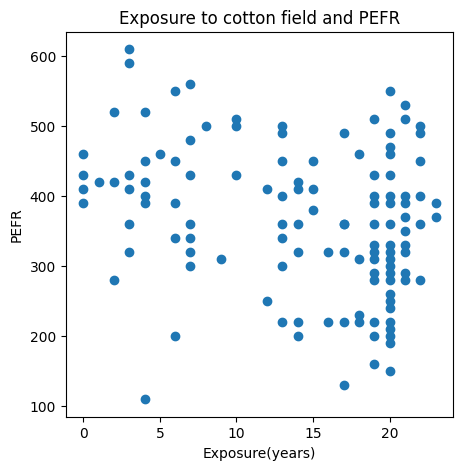

In [5]:
fig , ax = plt.subplots(figsize=(5 , 5))
ax.scatter(lung['Exposure'] , lung['PEFR'])
ax.set_xlabel('Exposure(years)')
ax.set_ylabel('PEFR')
ax.set_title('Exposure to cotton field and PEFR')
plt.show()

In [6]:
import seaborn as sns
plt.style.use('ggplot')

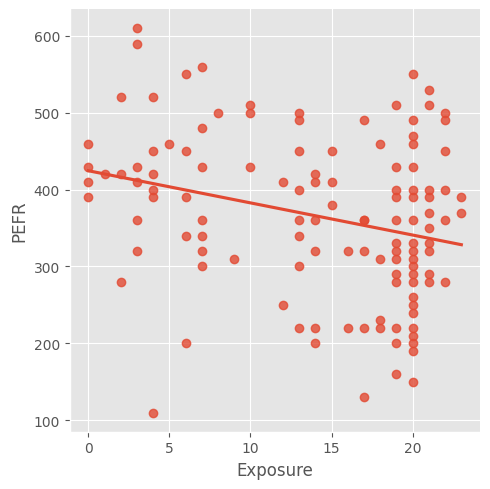

In [7]:
sns.lmplot(x='Exposure' , 
           y='PEFR', 
           data = lung , 
           ci= None , 
           )
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
predictor = ['Exposure']
outcome = 'PEFR'

model = LinearRegression()
model.fit(lung[predictor] , lung[outcome])


print(f"Intercept: {model.intercept_:.3f}")
print(f"Exposure Coefficient: {model.coef_[0]:.3f}")

Intercept: 424.583
Exposure Coefficient: -4.185


In [10]:
fitted = model.predict(lung[predictor])
residual = lung[outcome] - fitted

In [11]:
RSS = np.sum(residual.values ** 2)
print(f"Residual Sum of Squares: {RSS:.4f}")

Residual Sum of Squares: 1234764.2857


### Multiple Linear Regression

In [12]:
house = get_dataset(url="https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/house_sales.csv", 
                    file_name  = "house_sales")
house = pd.read_csv("Data/house_sales.csv" , sep="\t")
house.head()

File already exists


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


In [13]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms',
            'Bedrooms', 'BldgGrade']

house[subset].head()

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,300805.0,2400,9373,3.00,6,7
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7


In [14]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms',
            'Bedrooms', 'BldgGrade']
label = 'AdjSalePrice'

house_lr = LinearRegression()
house_lr.fit(house[predictors] , house[label])

print(f"Intercept: {house_lr.intercept_:.3f}")
print("Coefficients: ")
for name, coeff in zip(predictors , house_lr.coef_):
    print(f"{name} : {coeff:.3f}")


Intercept: -521871.368
Coefficients: 
SqFtTotLiving : 228.831
SqFtLot : -0.060
Bathrooms : -19442.840
Bedrooms : -47769.955
BldgGrade : 106106.963


In [15]:
from sklearn.metrics import root_mean_squared_error , r2_score

In [16]:
fitted = house_lr.predict(house[predictors])
RMSE = root_mean_squared_error(house[label] , fitted)
r2 = r2_score(house[label] , fitted)
print(f'RMSE: {RMSE:.0f}')
print(f'r2: {r2:.4f}')

RMSE: 261220
r2: 0.5406


In [17]:
import statsmodels.api as sm 
import statsmodels.formula.api as smf 


In [18]:
model = sm.OLS(house[label] , house[predictors].assign(const = 1))
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Mon, 02 Jun 2025   Prob (F-statistic):               0.00
Time:                        17:04:55   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694      0.000     221.189     236.472
SqFtLot          -0.0605      0.061     -0.988      0.323      -0.180       0.059
Bathrooms     -1.944e+04   3625.388     -5.363      0.000   -2.65e+04   -1.23e+04
Bedrooms      -4.777e+04   2489.732    -19.187      0.000   -5.27e+04   -4.29e+04
BldgGrade      1.061e+05   2396.445     44.277      0.000    1.01e+05    1.11e+05
const         -5.219e+05   1.57e+04    -33.342      0.000   -5.53e+05   -4.91e+05
==============================================================================
Omnibus:                    29676.557   Durbin-Watson:                   1.247
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         19390738.346
Skew:                           6.889   Prob(JB):                         0.00
Kurtosis:                     145.559   Cond. No.                     2.86e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.86e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [33]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade',
 'PropertyType', 'NbrLivingUnits', 'SqFtFinBasement', 'YrBuilt',
 'YrRenovated', 'NewConstruction']
X = pd.get_dummies(house[predictors], drop_first=True)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]


### Stepwise Regression

In [20]:
from dmba import stepwise_selection, forward_selection, backward_elimination, AIC_score

In [34]:
y = house[label]
def train_model(variables):
    if len(variables) == 0: 
        return None 
    model = LinearRegression()
    model.fit(X[variables] , y )
    return model 

def score_model(model, variables):
    if len(variables) == 0: 
        return AIC_score(y, [y.mean()] * len(y) , model, df = 1)
    return AIC_score(y, model.predict(X[variables]), model)

In [35]:
best_model, best_variables = stepwise_selection(X.columns , train_model,
                                                score_model, verbose= True)
print(f"Intercept: {best_model.intercept_:.3f}")
print("Coefficient")
for name, coef in zip(best_variables , best_model.coef_):
    print(f"{name} : {coef}")

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt
Step: score=627784.16, add Bedrooms
Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement
Step: score=627524.98, add PropertyType_Single Family
Step: score=627524.98, unchanged None
Intercept: 6178645.017
Coefficient
SqFtTotLiving : 199.2775530420158
BldgGrade : 137159.5602261976
YrBuilt : -3565.424939249463
Bedrooms : -51947.38367361413
Bathrooms : 42396.16452772056
PropertyType_Townhouse : 84479.16203299937
SqFtFinBasement : 7.046974967583083
PropertyType_Single Family : 22912.05518701767


In [37]:
best_model, best_variables = backward_elimination(X.columns , train_model,
                                                score_model, verbose= True)
print(f"Intercept: {best_model.intercept_:.3f}")
print("Coefficient")
for name, coef in zip(best_variables , best_model.coef_):
    print(f"{name} : {coef}")

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=627530.36
Step: score=627528.47, remove NbrLivingUnits
Step: score=627526.65, remove NewConstruction
Step: score=627525.08, remove YrRenovated
Step: score=627524.98, remove SqFtLot
Step: score=627524.98, remove None
Intercept: 6178645.017
Coefficient
SqFtTotLiving : 199.2775530420138
Bathrooms : 42396.16452771995
Bedrooms : -51947.383673613476
BldgGrade : 137159.560226197
SqFtFinBasement : 7.046974967561255
YrBuilt : -3565.4249392494003
PropertyType_Single Family : 22912.05518701774
PropertyType_Townhouse : 84479.16203299782
